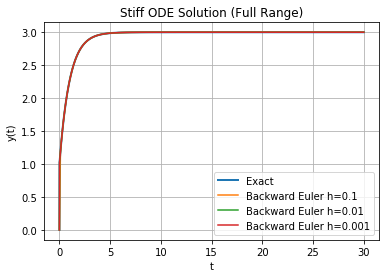

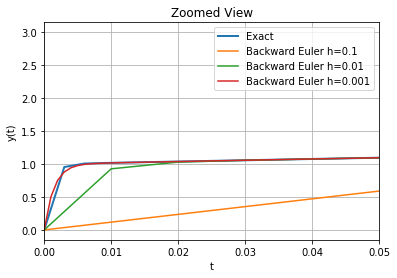

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Backward Euler method
def backward_euler(y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h, dtype=float)
    y_values = np.zeros_like(t_values, dtype=float)
    y_values[0] = y0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i-1]
        y_values[i] = (y_prev + h*(3000 - 2000*np.exp(-t_next))) / (1 + 1000*h)

    return t_values, y_values

# Exact solution
def exact_solution(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Parameters
y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001]

# Create exact solution
t_exact = np.linspace(t0, tf, 10000)
y_exact = exact_solution(t_exact)

#Plot 1: full
plt.figure()

plt.plot(t_exact, y_exact, label='Exact', linewidth=2)

for h in h_values:
    t_be, y_be = backward_euler(y0, t0, tf, h)
    plt.plot(t_be, y_be, label=f'Backward Euler h={h}')

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Stiff ODE Solution (Full Range)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: zoomed
plt.figure()

plt.plot(t_exact, y_exact, label='Exact', linewidth=2)

for h in h_values:
    t_be, y_be = backward_euler(y0, t0, tf, h)
    plt.plot(t_be, y_be, label=f'Backward Euler h={h}')

plt.xlim(0, 0.05)  # zoom to see stiffness
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Zoomed View')
plt.legend()
plt.grid(True)
plt.show()
